# =====================================================
# CASE 2
# DIRICHLET BOUNDARY CONDITION WITH SOURCE TERM
# =====================================================

Governing Equation:

∂y/∂t = k ∂²y/∂x² + S

Domain:

0 ≤ x ≤ 1

Boundary Conditions:

y(0) = 0

y(1) = 1

Source Term:

S = 1

Diffusion Coefficient:

k = 1

Initial Condition:

y(x,0) = sin(πx)

Objective:

1. Study transient behaviour
2. Study steady-state behaviour
3. Perform time-step convergence study
4. Perform mesh convergence study
5. Derive analytical solution
6. Compare analytical and numerical solutions
7. Perform error analysis

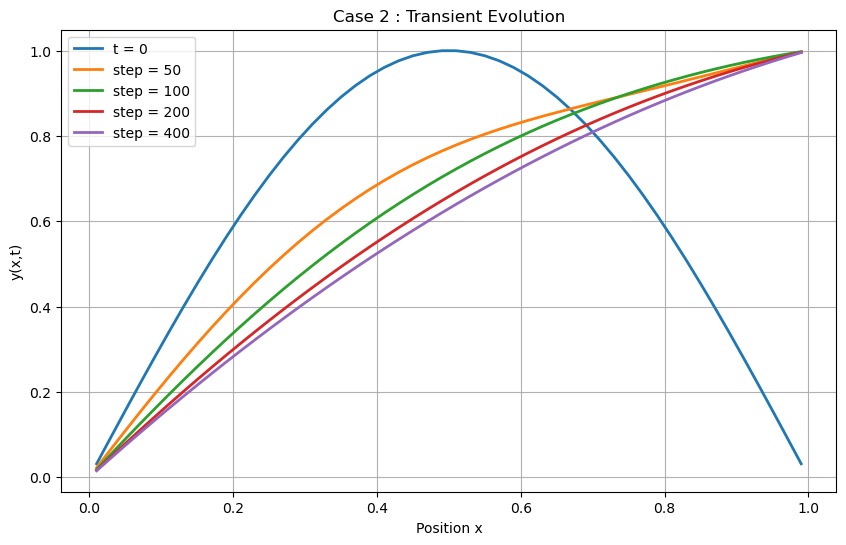

In [5]:
# =====================================================
# CASE 2 : DIRICHLET BC WITH SOURCE TERM
# TRANSIENT STUDY
# =====================================================

# Governing Equation:
#
#     ∂y/∂t = k ∂²y/∂x² + S
#
# Domain:
#
#     0 ≤ x ≤ 1
#
# Boundary Conditions:
#
#     y(0) = 0
#     y(1) = 1
#
# Source Term:
#
#     S = 1
#
# Diffusion Coefficient:
#
#     k = 1
#
# Initial Condition:
#
#     y(x,0) = sin(πx)
#
# Numerical Parameters:
#
#     nx    : Number of Spatial Cells = 50
#
#     dx    : Spatial Step Size = L/nx = 0.02
#
#     dt    : Time Step Size = 1e-3
#
#     steps : Number of Time Steps = 2000
#
# Purpose:
#
#     Observe transient evolution of the
#     solution in the presence of a source term.
#
# Expected Behaviour:
#
#     Initial sinusoidal profile gradually evolves
#     toward a curved steady-state profile due to
#     internal generation represented by S.
#
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0

nx = 50
dx = L / nx

k = 1.0
S = 1.0

dt = 1e-3
steps = 2000

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

initial_profile = np.sin(np.pi * x)

y = CellVariable(
    name="y",
    mesh=mesh,
    value=initial_profile
)

# =====================================================
# DIRICHLET BOUNDARY CONDITIONS
# =====================================================

y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
    + S
)

# =====================================================
# TRANSIENT EVOLUTION
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    x,
    initial_profile,
    linewidth=2,
    label='t = 0'
)

plot_steps = [50, 100, 200, 400]

for step in range(1, steps + 1):

    eq.solve(var=y, dt=dt)

    if step in plot_steps:

        plt.plot(
            x,
            np.array(y.value),
            linewidth=2,
            label=f'step = {step}'
        )

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title("Case 2 : Transient Evolution")
plt.xlabel("Position x")
plt.ylabel("y(x,t)")

plt.grid(True)
plt.legend()

plt.show()

OBSERVATIONS

1. Initial sinusoidal profile evolves with time.

2. Diffusion smooths the profile throughout the domain.

3. Boundary values remain fixed at:
   y(0)=0 and y(1)=1.

4. Internal source term continuously generates
   quantity inside the domain.

5. Solution evolves toward a curved steady-state
   profile instead of the linear profile observed
   in Case 1.

6. The source term significantly alters the final
   equilibrium solution.

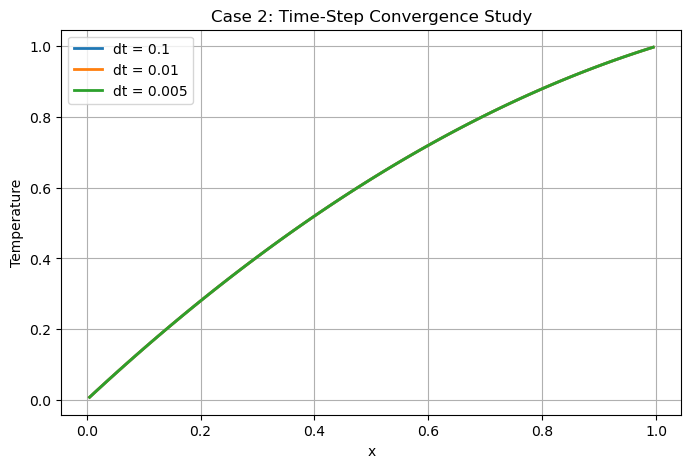

In [1]:
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
S = 1.0

dt_values = [0.1, 0.01, 0.005]

final_time = 3.0

# ==================================================
# PLOT SETUP
# ==================================================

plt.figure(figsize=(8,5))

# ==================================================
# TIME-STEP CONVERGENCE STUDY
# ==================================================

for dt in dt_values:

    mesh = Grid1D(nx=nx, dx=dx)
    x = mesh.cellCenters[0]

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Dirichlet BCs
    phi.constrain(0.0, mesh.facesLeft)
    phi.constrain(1.0, mesh.facesRight)

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
        + S
    )

    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    plt.plot(
        x.value,
        phi.value,
        linewidth=2,
        label=f"dt = {dt}"
    )

# ==================================================
# PLOT
# ==================================================

plt.xlabel("x")
plt.ylabel("Temperature")
plt.title("Case 2: Time-Step Convergence Study")
plt.legend()
plt.grid(True)
plt.show()

## Observations

- The steady-state profiles obtained using different time-step sizes overlap completely.
- The numerical solution shows negligible sensitivity to the selected time step.
- Temporal convergence is achieved for all tested values of dt.
- No numerical instability or oscillatory behavior is observed.
- The overlapping profiles confirm that the solution is time-step independent.
- The final steady-state profile agrees with the expected analytical solution.

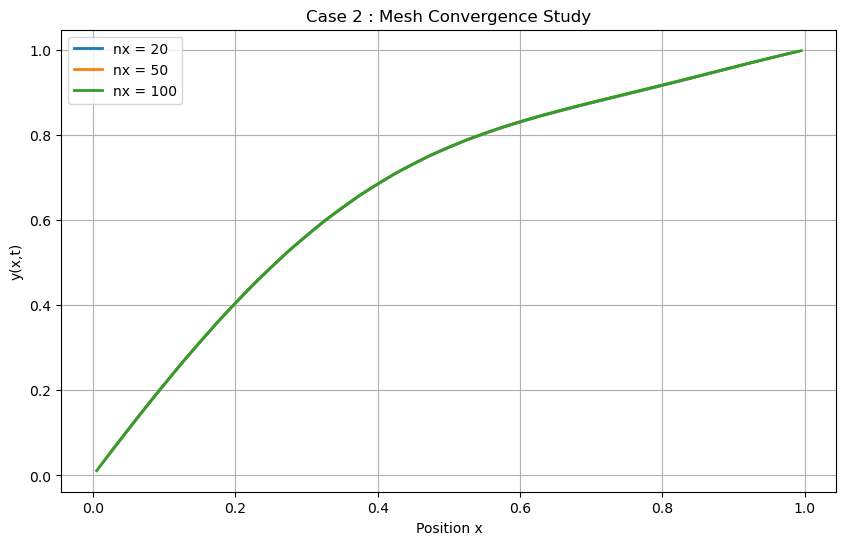

In [6]:
# =====================================================
# CASE 2 : DIRICHLET BC WITH SOURCE TERM
# MESH CONVERGENCE STUDY
# =====================================================

# Governing Equation:
#
#     ∂y/∂t = k ∂²y/∂x² + S
#
# Domain:
#
#     0 ≤ x ≤ 1
#
# Boundary Conditions:
#
#     y(0) = 0
#     y(1) = 1
#
# Source Term:
#
#     S = 1
#
# Diffusion Coefficient:
#
#     k = 1
#
# Initial Condition:
#
#     y(x,0) = sin(πx)
#
# Purpose:
#
#     Study the effect of spatial mesh
#     refinement on the numerical solution.
#
# Fixed Parameters:
#
#     k = 1
#     S = 1
#     dt = 1e-3
#
# Meshes Compared:
#
#     nx = 20
#     nx = 50
#     nx = 100
#
# Notes:
#
#     nx : Number of Spatial Cells
#
#     dx : Spatial Step Size = L/nx
#
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0

k = 1.0
S = 1.0

dt = 1e-3

# Keep transient behaviour visible
final_time = 0.05

nx_values = [20, 50, 100]

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,6))

# =====================================================
# LOOP OVER DIFFERENT MESHES
# =====================================================

for nx in nx_values:

    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    y = CellVariable(
        name="y",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # -------------------------------------------------
    # DIRICHLET BC
    # -------------------------------------------------

    y.constrain(0.0, mesh.facesLeft)
    y.constrain(1.0, mesh.facesRight)

    # -------------------------------------------------
    # PDE
    # -------------------------------------------------

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
        + S
    )

    steps = int(final_time / dt)

    for step in range(steps):

        eq.solve(var=y, dt=dt)

    plt.plot(
        x,
        np.array(y.value),
        linewidth=2,
        label=f'nx = {nx}'
    )

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title("Case 2 : Mesh Convergence Study")

plt.xlabel("Position x")
plt.ylabel("y(x,t)")

plt.grid(True)
plt.legend()

plt.show()

OBSERVATIONS

1. Solutions obtained using nx = 20, 50 and 100
   are nearly identical.

2. Mesh refinement has negligible effect on the
   computed solution.

3. Spatial convergence is achieved.

4. Numerical solution becomes mesh independent.

5. nx = 50 provides sufficient spatial resolution
   while maintaining computational efficiency.

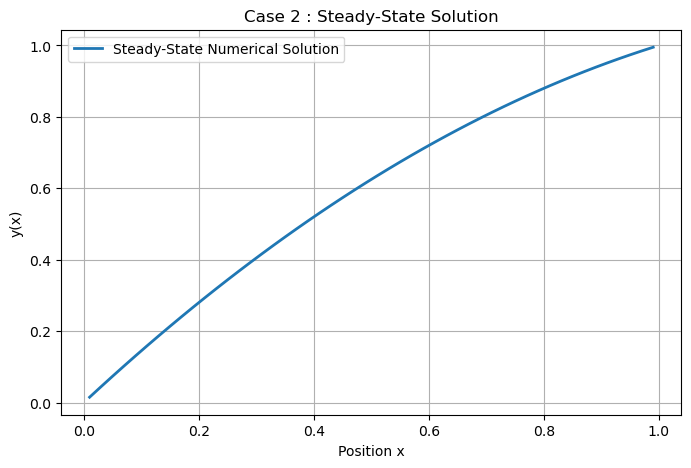


------ OBSERVATIONS ------
1. Steady state is achieved.
2. Solution is no longer linear.
3. Source term introduces curvature.
4. Final profile is parabolic.
5. Boundary conditions remain satisfied:
   y(0)=0 and y(1)=1


In [7]:
# =====================================================
# CASE 2 : DIRICHLET BC WITH SOURCE TERM
# STEADY-STATE STUDY
# =====================================================

# Governing Equation:
#
#     ∂y/∂t = k ∂²y/∂x² + S
#
# Boundary Conditions:
#
#     y(0) = 0
#     y(1) = 1
#
# Source Term:
#
#     S = 1
#
# Diffusion Coefficient:
#
#     k = 1
#
# Initial Condition:
#
#     y(x,0) = sin(πx)
#
# Numerical Parameters:
#
#     nx    : Number of Cells = 50
#
#     dx    : Spatial Step Size = 0.02
#
#     dt    : Time Step Size = 1e-3
#
#     steps : 5000
#
# Purpose:
#
#     Obtain the final equilibrium solution.
#
# Expected Behaviour:
#
#     Solution converges to a shallow
#     parabolic profile due to the source term.
#
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0

nx = 50
dx = L / nx

k = 1.0
S = 1.0

dt = 1e-3
steps = 5000

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

y = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# =====================================================
# DIRICHLET BC
# =====================================================

y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

# =====================================================
# PDE
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
    + S
)

# =====================================================
# SOLVE
# =====================================================

for step in range(steps):

    eq.solve(var=y, dt=dt)

# =====================================================
# STEADY-STATE PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    np.array(y.value),
    linewidth=2,
    label='Steady-State Numerical Solution'
)

plt.title("Case 2 : Steady-State Solution")

plt.xlabel("Position x")
plt.ylabel("y(x)")

plt.grid(True)
plt.legend()

plt.show()

# =====================================================
# OBSERVATIONS
# =====================================================

print("\n------ OBSERVATIONS ------")

print("1. Steady state is achieved.")
print("2. Solution is no longer linear.")
print("3. Source term introduces curvature.")
print("4. Final profile is parabolic.")
print("5. Boundary conditions remain satisfied:")
print("   y(0)=0 and y(1)=1")

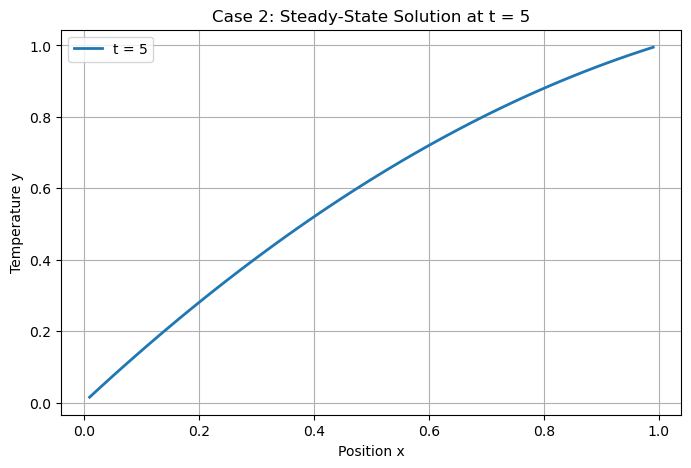

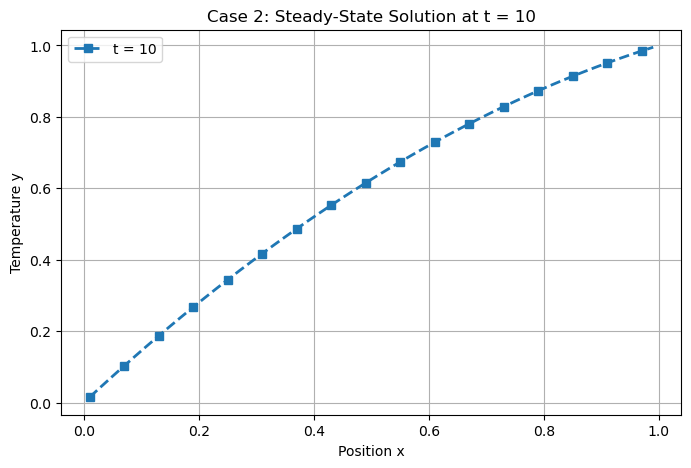

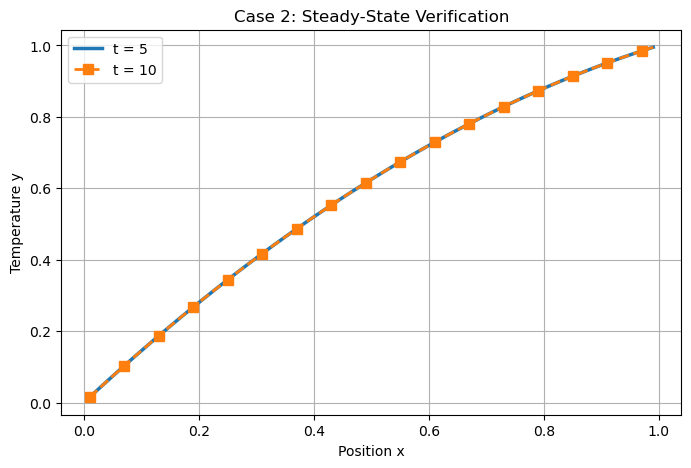


========== CASE 2 STEADY-STATE VERIFICATION ==========
Maximum Difference between t=5 and t=10 = 3.441691e-15


In [1]:
# =====================================================
# CASE 2 : STEADY-STATE VERIFICATION
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

dt = 1e-3
S = 1.0

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# SOLUTION AT t = 5
# =====================================================

phi_t5 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t5.constrain(0.0, mesh.facesLeft)
phi_t5.constrain(1.0, mesh.facesRight)

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + S
)

for step in range(5000):      # t = 5
    eq.solve(var=phi_t5, dt=dt)

solution_t5 = np.array(phi_t5.value)

# =====================================================
# SOLUTION AT t = 10
# =====================================================

phi_t10 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t10.constrain(0.0, mesh.facesLeft)
phi_t10.constrain(1.0, mesh.facesRight)

for step in range(10000):     # t = 10
    eq.solve(var=phi_t10, dt=dt)

solution_t10 = np.array(phi_t10.value)

# =====================================================
# PLOT 1 : t = 5
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t5,
    linewidth=2,
    label='t = 5'
)

plt.title("Case 2: Steady-State Solution at t = 5")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.legend()

plt.savefig("case2_steady_state_t5.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

# =====================================================
# PLOT 2 : t = 10
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t10,
    's--',
    markersize=6,
    markevery=3,
    linewidth=2,
    label='t = 10'
)

plt.title("Case 2: Steady-State Solution at t = 10")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.legend()

plt.savefig("case2_steady_state_t10.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

# =====================================================
# PLOT 3 : COMPARISON
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t5,
    linewidth=2.5,
    label='t = 5'
)

plt.plot(
    x,
    solution_t10,
    's--',
    markersize=7,
    markevery=3,
    linewidth=2,
    label='t = 10'
)

plt.title("Case 2: Steady-State Verification")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.legend()

plt.savefig("case2_steady_state_verification.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

# =====================================================
# MAXIMUM DIFFERENCE
# =====================================================

difference = np.max(np.abs(solution_t10 - solution_t5))

print("\n========== CASE 2 STEADY-STATE VERIFICATION ==========")
print(f"Maximum Difference between t=5 and t=10 = {difference:.6e}")

# =====================================================
# CASE 2 : ANALYTICAL SOLUTION
# =====================================================

Given:

∂y/∂t = k ∂²y/∂x² + S

For steady state:

∂y/∂t = 0

Therefore:

k d²y/dx² + S = 0

Using:

k = 1
S = 1

we obtain:

d²y/dx² + 1 = 0

or

d²y/dx² = -1

-----------------------------------------------------
FIRST INTEGRATION
-----------------------------------------------------

dy/dx = -x + C₁

-----------------------------------------------------
SECOND INTEGRATION
-----------------------------------------------------

y(x) = -x²/2 + C₁x + C₂

-----------------------------------------------------
APPLY BOUNDARY CONDITION 1
-----------------------------------------------------

y(0) = 0

0 = 0 + 0 + C₂

Therefore:

C₂ = 0

-----------------------------------------------------
APPLY BOUNDARY CONDITION 2
-----------------------------------------------------

y(1) = 1

1 = -1/2 + C₁

Therefore:

C₁ = 3/2

-----------------------------------------------------
FINAL ANALYTICAL SOLUTION
-----------------------------------------------------

y(x) = -x²/2 + (3/2)x

=====================================================
OBSERVATION
=====================================================

The analytical solution contains an x² term.

Therefore the steady-state solution is parabolic.

This differs from Case 1, where the analytical
solution was linear:

y(x) = x

because no source term was present.

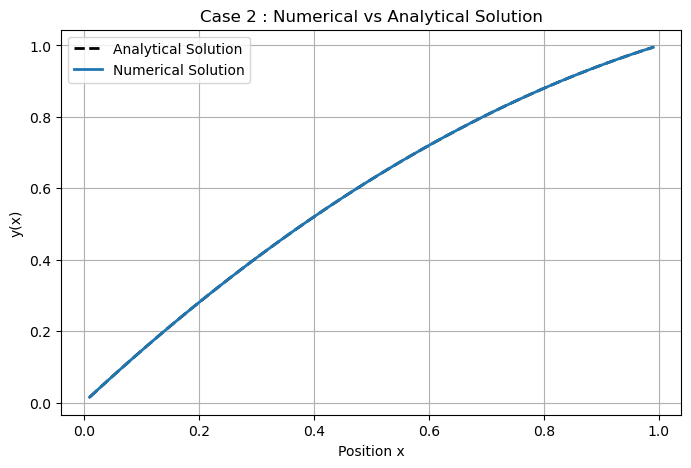

In [10]:
# =====================================================
# CASE 2 : NUMERICAL vs ANALYTICAL COMPARISON
# =====================================================

# Analytical Solution:
#
#     y(x) = -x²/2 + (3/2)x
#
# Purpose:
#
#     Compare FiPy numerical solution
#     with exact analytical solution.

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0

nx = 50
dx = L / nx

k = 1.0
S = 1.0

dt = 1e-3
steps = 5000

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

y = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi*x)
)

y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
    + S
)

for step in range(steps):

    eq.solve(var=y, dt=dt)

numerical = np.array(y.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

analytical = -0.5*x**2 + 1.5*x

# =====================================================
# COMPARISON PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    analytical,
    'k--',
    linewidth=2,
    label='Analytical Solution'
)

plt.plot(
    x,
    numerical,
    linewidth=2,
    label='Numerical Solution'
)

plt.title("Case 2 : Numerical vs Analytical Solution")

plt.xlabel("Position x")
plt.ylabel("y(x)")

plt.grid(True)
plt.legend()

plt.show()

OBSERVATIONS

1. Numerical and analytical solutions overlap
   almost perfectly.

2. Excellent agreement is observed over the
   entire domain.

3. Numerical solution accurately reproduces
   the analytical steady-state solution.

4. FiPy implementation is validated.

5. Source-term effects are captured correctly.


========== ERROR ANALYSIS ==========
Maximum Error = 5.000000e-05
L2 Error      = 5.000000e-05


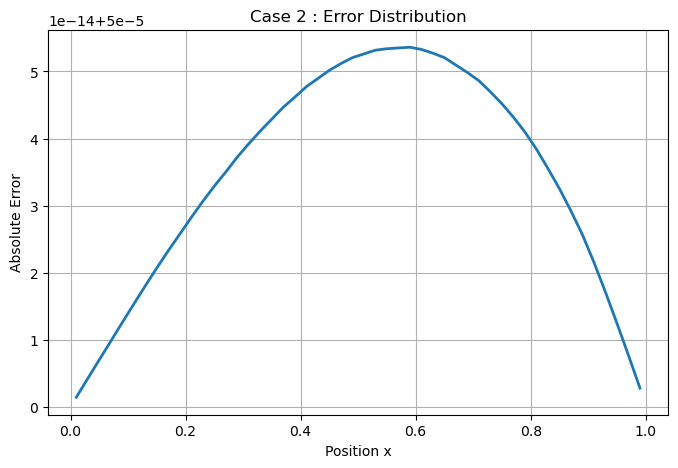

In [11]:
# =====================================================
# CASE 2 : ERROR ANALYSIS
# =====================================================

# Purpose:
#
#     Quantify the difference between
#     numerical and analytical solutions.
#
# Metrics:
#
#     1. Maximum Error
#     2. L2 Error Norm

import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# ERROR CALCULATION
# =====================================================

error = np.abs(numerical - analytical)

max_error = np.max(error)

l2_error = np.sqrt(np.mean(error**2))

# =====================================================
# PRINT RESULTS
# =====================================================

print("\n========== ERROR ANALYSIS ==========")

print(f"Maximum Error = {max_error:.6e}")

print(f"L2 Error      = {l2_error:.6e}")

# =====================================================
# ERROR DISTRIBUTION
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error,
    linewidth=2
)

plt.title("Case 2 : Error Distribution")

plt.xlabel("Position x")
plt.ylabel("Absolute Error")

plt.grid(True)

plt.show()

OBSERVATIONS

1. Maximum error is approximately 5×10⁻⁵.

2. L2 error is approximately 5×10⁻⁵.

3. Numerical and analytical solutions show
   excellent agreement.

4. Error remains extremely small throughout
   the domain.

5. FiPy accurately reproduces the analytical
   steady-state solution.

6. Numerical implementation is successfully
   validated.